# 03 · Montando o GPT e gerando texto — *Victor*

**Entra:** tokenizer + embeddings (01) e `MultiHeadAttention` (02). **Sai:** `GPTModel` + `generate` → treinados no notebook 04.

Perguntas:
1. Consigo gerar texto com sentido **sem** pré-treino?
2. O que acontece se eu remover alguma etapa do Transformer (normalização, FFN)?
3. Posso usar ReLU na FFN?
4. Qual a diferença entre 12 e 24 camadas?

In [1]:
import time

import matplotlib.pyplot as plt
import tiktoken
import torch

from aula import GPT_CONFIG_124M, variante, n_params
from llms_from_scratch.ch04 import GPTModel, TransformerBlock, GELU, generate_text_simple

torch.manual_seed(123)
cfg = GPT_CONFIG_124M
bpe = tiktoken.get_encoding("gpt2")
batch = torch.tensor([bpe.encode("Every effort moves you"), bpe.encode("Every day holds a")])
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


## 1. Um bloco Transformer, passo a passo
`LayerNorm → atenção → + atalho → LayerNorm → FFN → + atalho`. Vamos chamar cada peça na mão e olhar o tensor.

In [2]:
tok_emb = torch.nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
pos_emb = torch.nn.Embedding(cfg["context_length"], cfg["emb_dim"])
bloco = TransformerBlock(cfg).eval()

def info(nome, t):
    print(f"{nome:28s} shape={tuple(t.shape)}  média={t.mean():+.3f}  desvio={t.std():.3f}")

with torch.no_grad():
    x = tok_emb(batch) + pos_emb(torch.arange(batch.shape[1]))
    info("embeddings", x)
    h = bloco.norm1(x);             info("1. LayerNorm", h)
    h = bloco.att(h);               info("2. multi-head attention", h)
    x = x + h;                      info("3. + atalho (residual)", x)
    h = bloco.norm2(x);             info("4. LayerNorm", h)
    h = bloco.ff.layers[0](h);      info("5. FFN: expande 768→3072", h)
    h = bloco.ff.layers[1](h);      info("6. GELU", h)
    h = bloco.ff.layers[2](h);      info("7. FFN: volta 3072→768", h)
    x = x + h;                      info("8. + atalho (residual)", x)
    assert torch.allclose(x, bloco(tok_emb(batch) + pos_emb(torch.arange(batch.shape[1]))), atol=1e-5)

embeddings                   shape=(2, 4, 768)  média=+0.009  desvio=1.420
1. LayerNorm                 shape=(2, 4, 768)  média=+0.000  desvio=1.000
2. multi-head attention      shape=(2, 4, 768)  média=-0.002  desvio=0.238
3. + atalho (residual)       shape=(2, 4, 768)  média=+0.007  desvio=1.442
4. LayerNorm                 shape=(2, 4, 768)  média=+0.000  desvio=1.000
5. FFN: expande 768→3072     shape=(2, 4, 3072)  média=-0.002  desvio=0.580
6. GELU                      shape=(2, 4, 3072)  média=+0.115  desvio=0.326
7. FFN: volta 3072→768       shape=(2, 4, 768)  média=+0.002  desvio=0.199
8. + atalho (residual)       shape=(2, 4, 768)  média=+0.009  desvio=1.456


Entra `batch × tokens × 768`, sai **o mesmo formato** → dá para empilhar quantos blocos quisermos.

### GELU vs ReLU

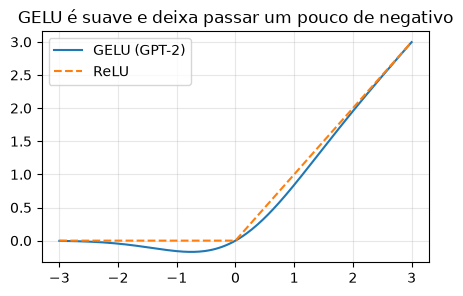

In [3]:
z = torch.linspace(-3, 3, 200)
plt.figure(figsize=(5, 3))
plt.plot(z, GELU()(z), label="GELU (GPT-2)")
plt.plot(z, torch.relu(z), "--", label="ReLU")
plt.legend(); plt.grid(alpha=.3); plt.title("GELU é suave e deixa passar um pouco de negativo")
plt.show()

## 2. O GPT inteiro: embeddings + 12 blocos + LayerNorm final + cabeça de saída

In [4]:
torch.manual_seed(123)
model = GPTModel(cfg).eval()
print(model.trf_blocks[0])
total = n_params(model)
print(f"\nparâmetros: {total:,}")
print(f"sem contar out_head (weight tying do GPT-2 original): {total - model.out_head.weight.numel():,}")
print(f"memória em float32: {total * 4 / 1e6:.0f} MB")

TransformerBlock(
  (att): MultiHeadAttention(
    (W_query): Linear(in_features=768, out_features=768, bias=False)
    (W_key): Linear(in_features=768, out_features=768, bias=False)
    (W_value): Linear(in_features=768, out_features=768, bias=False)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (ff): FeedForward(
    (layers): Sequential(
      (0): Linear(in_features=768, out_features=3072, bias=True)
      (1): GELU()
      (2): Linear(in_features=3072, out_features=768, bias=True)
    )
  )
  (norm1): LayerNorm()
  (norm2): LayerNorm()
  (drop_resid): Dropout(p=0.1, inplace=False)
)

parâmetros: 163,009,536
sem contar out_head (weight tying do GPT-2 original): 124,412,160
memória em float32: 652 MB


In [5]:
with torch.no_grad():
    logits = model(batch)
print("logits:", tuple(logits.shape), "→ para cada posição, uma nota para cada um dos 50.257 tokens")

logits: (2, 4, 50257) → para cada posição, uma nota para cada um dos 50.257 tokens


## 3. Gerar texto = prever o próximo token em loop

In [6]:
def proximo_token(model, ids, k=5):
    with torch.no_grad():
        probs = torch.softmax(model(ids)[0, -1], dim=-1)
    top = torch.topk(probs, k)
    for p, i in zip(top.values, top.indices):
        print(f"  {bpe.decode([i.item()])!r:>15}  {p:.5f}")

ids = torch.tensor([bpe.encode("Hello, I am")])
print("top-5 para o próximo token (modelo aleatório):")
proximo_token(model, ids)

saida = generate_text_simple(model, ids, max_new_tokens=15, context_size=cfg["context_length"])
print("\ntexto gerado:", bpe.decode(saida[0].tolist()))

top-5 para o próximo token (modelo aleatório):
       ' Feature'  0.00021
            '677'  0.00015
          'TRUMP'  0.00014
  ' participated'  0.00014
          'retch'  0.00014



texto gerado: Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous bore ITVEGIN ministriesysics


**Resposta à pergunta 1:** não. Com pesos aleatórios todas as probabilidades ficam ≈ 1/50257 ≈ 0,00002 e o texto é lixo.
A arquitetura é só o "encanamento"; o conhecimento vem do **pré-treino** (notebook 04).

## 4. 🔧 Removendo e trocando peças
`variante()` (em `aula.py`) pega o `GPTModel` do livro e troca LayerNorm por identidade, FFN por zero, ou GELU por ReLU.
Ainda sem treinar: olhamos parâmetros e o que acontece com os valores depois de 12 blocos.

In [7]:
def forward_stats(m):
    m.eval()
    with torch.no_grad():
        h = m.tok_emb(batch) + m.pos_emb(torch.arange(batch.shape[1]))
        h = m.trf_blocks(h)
    return h.std().item()

variantes = {
    "original": {},
    "sem LayerNorm": {"sem_norm": True},
    "sem FFN": {"sem_ffn": True},
    "FFN com ReLU": {"relu": True},
}
for nome, kw in variantes.items():
    torch.manual_seed(123)
    m = variante(cfg, **kw)
    print(f"{nome:15s} params={n_params(m):>12,}  desvio do sinal após 12 blocos={forward_stats(m):7.2f}")

original        params= 163,009,536  desvio do sinal após 12 blocos=   1.81


sem LayerNorm   params= 162,971,136  desvio do sinal após 12 blocos=   3.23


sem FFN         params= 106,340,352  desvio do sinal após 12 blocos=   1.68


FFN com ReLU    params= 163,009,536  desvio do sinal após 12 blocos=   1.88


- **Sem FFN:** perde ~⅔ dos parâmetros dos blocos — a FFN é onde fica a maior parte da "memória" do modelo.
- **Sem LayerNorm:** o sinal cresce bloco a bloco (os atalhos vão somando); em treino isso desestabiliza os gradientes.
- **ReLU:** mesmos parâmetros, só muda a não-linearidade.

O efeito **no aprendizado** a gente mede treinando essas variantes no notebook 04.

## 5. 🔧 12 vs 24 camadas

In [8]:
for n_camadas in [6, 12, 24, 48]:
    torch.manual_seed(123)
    m = GPTModel({**cfg, "n_layers": n_camadas}).eval()
    ids = torch.randint(0, cfg["vocab_size"], (1, 256))
    with torch.no_grad():
        t0 = time.perf_counter(); m(ids); dt = time.perf_counter() - t0
    print(f"{n_camadas:>2} camadas: {n_params(m) / 1e6:6.1f}M params | forward de 256 tokens: {dt * 1000:6.0f} ms")

 6 camadas:  120.5M params | forward de 256 tokens:     64 ms


12 camadas:  163.0M params | forward de 256 tokens:    105 ms


24 camadas:  248.0M params | forward de 256 tokens:    213 ms


48 camadas:  418.1M params | forward de 256 tokens:    630 ms


Cada bloco custa ~7M parâmetros (12·d²). Dobrar camadas ≈ dobra custo e memória dos blocos;
mais profundidade = mais etapas de "raciocínio" sobre a representação, **se** houver dados para treinar.
(GPT-2 medium tem 24 camadas, mas também aumenta `emb_dim` para 1024 — ver notebook 07.)

### ✅ Construto
`GPTModel(cfg)` + `generate_text_simple` → no notebook **04** vamos treinar esse modelo.